# WAWA EMG Analysis
**Navid's STM32 EMG System — Recordings 8 & 9**

### Known facts
- Header: `0xDEADBEEF`, Footer: `0xBEEFDEAD`
- Record size: **45 bytes**, sample rate: **500 Hz**
- Channels intended: RF (Ch0), BF (Ch1), Gas (Ch2), TA (Ch3) — Gas/TA cable too short
- IMU present on device

### ⚠️ Layout not confirmed — run inspection cells first, ask Navid for struct definition

### Recordings
- **Rec 8**: Stomp (MVC) → Walk
- **Rec 9**: Stomp (MVC) → Ramp up/down (repeated)

In [20]:
import struct
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
FS = 500  # Hz
RECORD_SIZE = 45

FILES = {'rec8': 'EMG_rec_8.bin', 'rec9': 'EMG_rec_9.bin'}

## 1. File inspection — header, size, record count

In [21]:
for name, path in FILES.items():
    with open(path, 'rb') as f:
        raw = f.read()
    header = struct.unpack('<I', raw[:4])[0]
    footer = struct.unpack('<I', raw[-4:])[0]
    payload = raw[4:-4]
    N = len(payload) // RECORD_SIZE
    remainder = len(payload) % RECORD_SIZE
    print(f"{name} ({path})")
    print(f"  Total bytes : {len(raw):,}")
    print(f"  Header      : {hex(header)}  (expected 0xdeadbeef)")
    print(f"  Footer      : {hex(footer)}  (expected 0xbeefdead)")
    print(f"  Records     : {N}  (remainder={remainder} bytes)")
    print(f"  Duration    : {N/FS:.1f}s at {FS} Hz")
    print()

rec8 (EMG_rec_8.bin)
  Total bytes : 1,162,988
  Header      : 0xdeadbeef  (expected 0xdeadbeef)
  Footer      : 0xbeefdead  (expected 0xbeefdead)
  Records     : 25844  (remainder=0 bytes)
  Duration    : 51.7s at 500 Hz

rec9 (EMG_rec_9.bin)
  Total bytes : 1,543,823
  Header      : 0xdeadbeef  (expected 0xdeadbeef)
  Footer      : 0xbeefdead  (expected 0xbeefdead)
  Records     : 34307  (remainder=0 bytes)
  Duration    : 68.6s at 500 Hz



## 2. Raw hex dump — first 5 records
Each row = one 45-byte record. Look for patterns.

In [22]:
with open('EMG_rec_8.bin', 'rb') as f:
    raw8 = f.read()
payload8 = raw8[4:-4]

print('Offset:     ' + '  '.join(f'{i:02d}' for i in range(RECORD_SIZE)))
print('-' * 145)
for r in range(5):
    rec = payload8[r*RECORD_SIZE:(r+1)*RECORD_SIZE]
    print(f'Record {r:02d}:  ' + '  '.join(f'{b:02x}' for b in rec))

Offset:     00  01  02  03  04  05  06  07  08  09  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44
-------------------------------------------------------------------------------------------------------------------------------------------------
Record 00:  14  4d  01  00  9b  05  09  07  7b  02  15  03  20  01  88  c5  08  1b  02  00  c5  fb  27  fd  36  ff  f5  fe  ac  00  00  09  3f  00  00  00  00  00  00  00  00  00  00  00  00
Record 01:  16  4d  01  00  95  05  fd  06  75  02  17  03  28  00  08  c6  a0  1b  f0  00  da  fb  92  fe  3a  ff  fe  fe  ad  00  10  09  3f  00  00  00  00  00  00  00  00  00  00  00  00
Record 02:  18  4d  01  00  8d  05  f3  06  6f  02  13  03  78  00  00  c8  88  1b  4e  01  30  fa  ac  fe  3a  ff  fe  fe  ad  00  10  09  3f  00  00  00  00  00  00  00  00  00  00  00  00
Record 03:  1a  4d  01  00  7f  05  e8  06  6b  02  0e  03  28  00  80  c6  b8  1b  84  ff

## 3. Timestamp analysis

In [23]:
N8 = len(payload8) // RECORD_SIZE
ts8 = np.array([struct.unpack('<I', payload8[i*RECORD_SIZE:i*RECORD_SIZE+4])[0] for i in range(N8)])
diffs = np.diff(ts8)

print(f"ts[0]={ts8[0]}, ts[-1]={ts8[-1]}, range={ts8[-1]-ts8[0]}")
print(f"Diff: mean={diffs.mean():.2f}, std={diffs.std():.3f}, min={diffs.min()}, max={diffs.max()}")
print(f"\nIf ts units = ms  → Fs = {1000/diffs.mean():.0f} Hz")
print(f"Dropped samples (diff > mean+3σ): {np.sum(diffs > diffs.mean()+3*diffs.std())}")

ts[0]=85268, ts[-1]=136954, range=51686
Diff: mean=2.00, std=0.000, min=2, max=2

If ts units = ms  → Fs = 500 Hz
Dropped samples (diff > mean+3σ): 0


## 4. Statistics for every 2-byte offset
Identifies which byte pairs are: constants, EMG (positive, moderate range), IMU (signed, high variance), or zeros.

In [24]:
offsets = list(range(0, RECORD_SIZE - 1, 2))
channels8 = {}
for off in offsets:
    channels8[off] = np.array([
        struct.unpack('<H', payload8[i*RECORD_SIZE+off:i*RECORD_SIZE+off+2])[0]
        for i in range(N8)
    ])

print(f"{'Offset':>8}  {'mean':>9} {'std':>9} {'min':>7} {'max':>7}  Notes")
print('-' * 70)
for off in offsets:
    v = channels8[off]
    vs = v.astype(np.int16)
    note = ''
    if v.std() < 1:          note = 'CONSTANT'
    elif v.max() == 4095:    note = 'ADC SATURATION (12-bit max)'
    elif v.max() < 5:        note = 'near-zero'
    elif vs.min() < -1000:   note = 'signed (IMU?)'
    elif v.std() > 2000:     note = 'high variance'
    elif 100 < v.mean() < 4000 and v.std() > 30: note = 'plausible EMG/ADC'
    print(f"  [{off:2d}-{off+1:2d}]  {v.mean():>9.1f} {v.std():>9.1f} {v.min():>7} {v.max():>7}  {note}")

  Offset       mean       std     min     max  Notes
----------------------------------------------------------------------
  [ 0- 1]    38114.6   17725.4       0   65534  signed (IMU?)
  [ 2- 3]        1.1       0.3       1       2  CONSTANT
  [ 4- 5]      293.2      76.2     169    1435  plausible EMG/ADC
  [ 6- 7]      449.4      83.1     307    1801  plausible EMG/ADC
  [ 8- 9]     1937.4    1177.1      89    4095  ADC SATURATION (12-bit max)
  [10-11]     1729.5    1221.4     181    4095  ADC SATURATION (12-bit max)
  [12-13]    48914.3   26221.9       0   65528  signed (IMU?)
  [14-15]    50264.6    2593.4   32768   62072  signed (IMU?)
  [16-17]     7130.8    6202.1       0   65528  signed (IMU?)
  [18-19]    35465.8   31287.4       0   65535  signed (IMU?)
  [20-21]    30466.0   30480.2       0   65535  signed (IMU?)
  [22-23]    33318.2   31432.3       0   65535  signed (IMU?)
  [24-25]    65150.9     155.9   64773   65532  
  [26-27]    65267.2      62.4   65026   65532  
  [

## 5. Plot every channel — full recording (uint16)
Orange = stomp/MVC window. EMG channels should spike here.

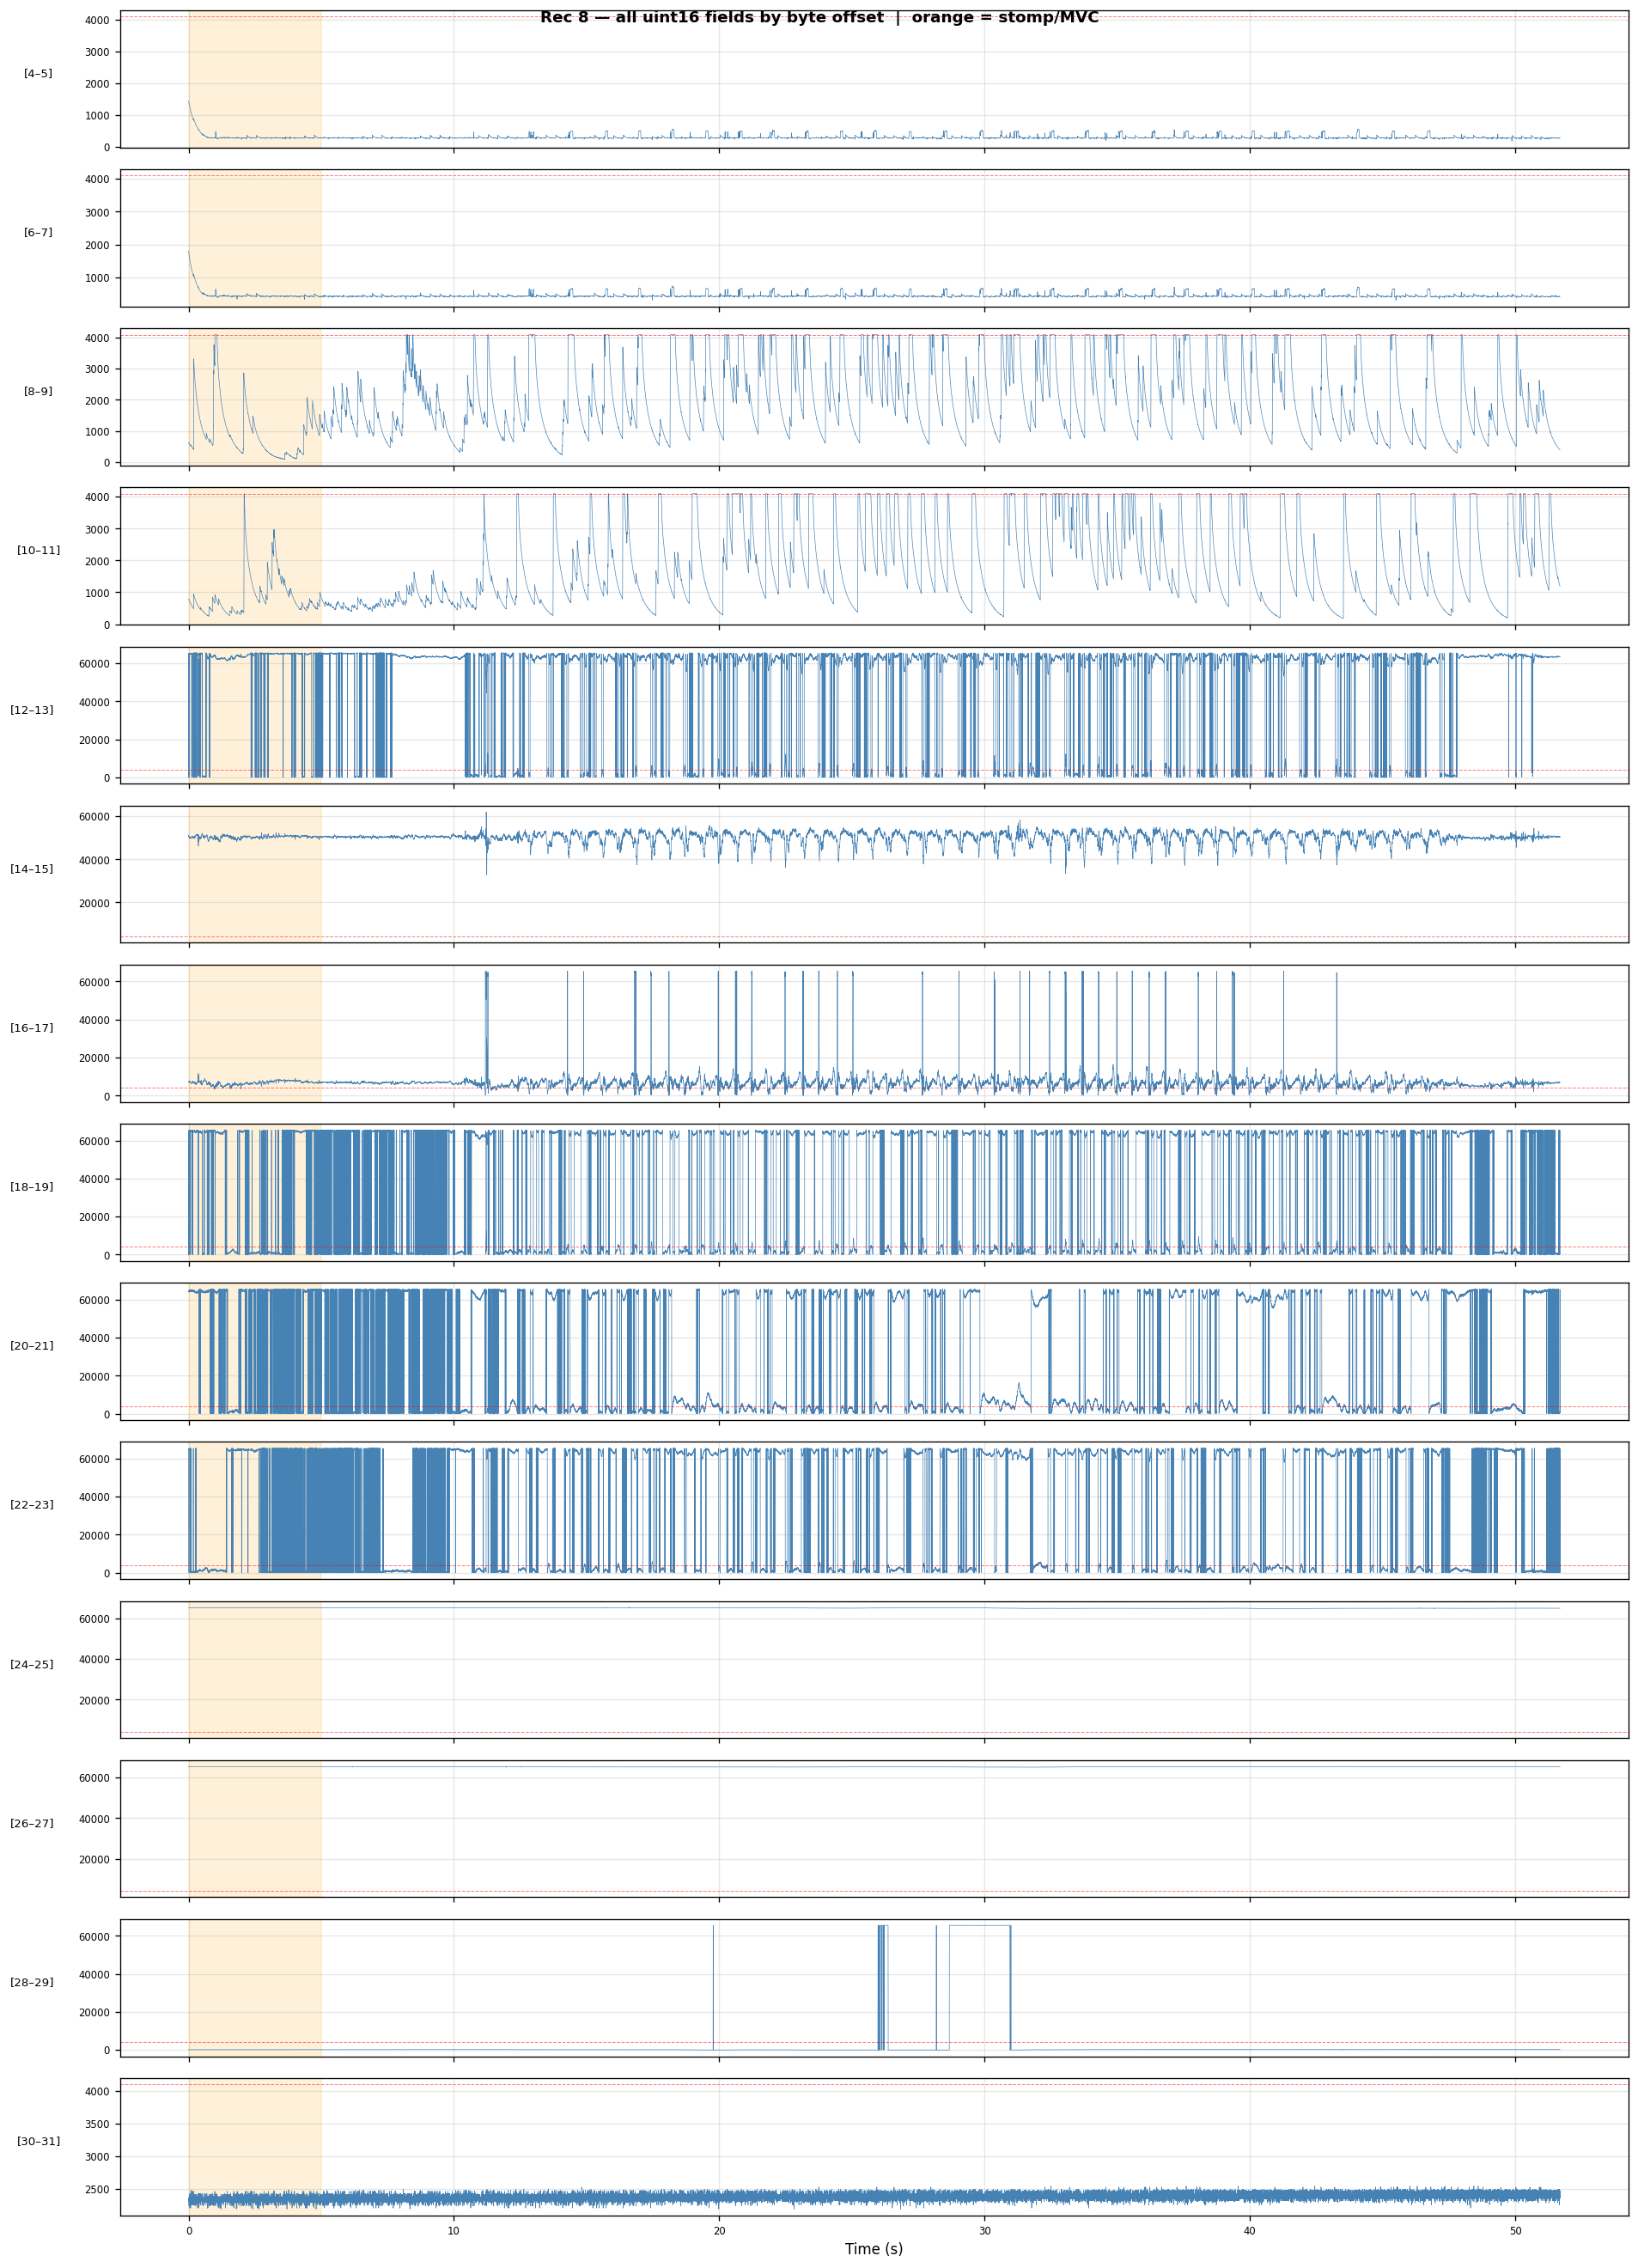

In [25]:
time8 = (ts8 - ts8[0]) / 1000.0  # ms -> seconds

plot_offsets = list(range(4, 32, 2))  # skip timestamp bytes 0-3 and trailing zeros
n_plot = len(plot_offsets)

fig, axes = plt.subplots(n_plot, 1, figsize=(16, n_plot * 1.6), sharex=True)
fig.suptitle('Rec 8 — all uint16 fields by byte offset  |  orange = stomp/MVC', fontsize=11, fontweight='bold')

for ax, off in zip(axes, plot_offsets):
    ax.plot(time8, channels8[off], lw=0.4, color='steelblue')
    ax.axvspan(0, 5, alpha=0.15, color='orange')
    ax.axhline(4095, color='red', lw=0.6, ls='--', alpha=0.5)
    ax.set_ylabel(f'[{off}–{off+1}]', fontsize=8, rotation=0, labelpad=32)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

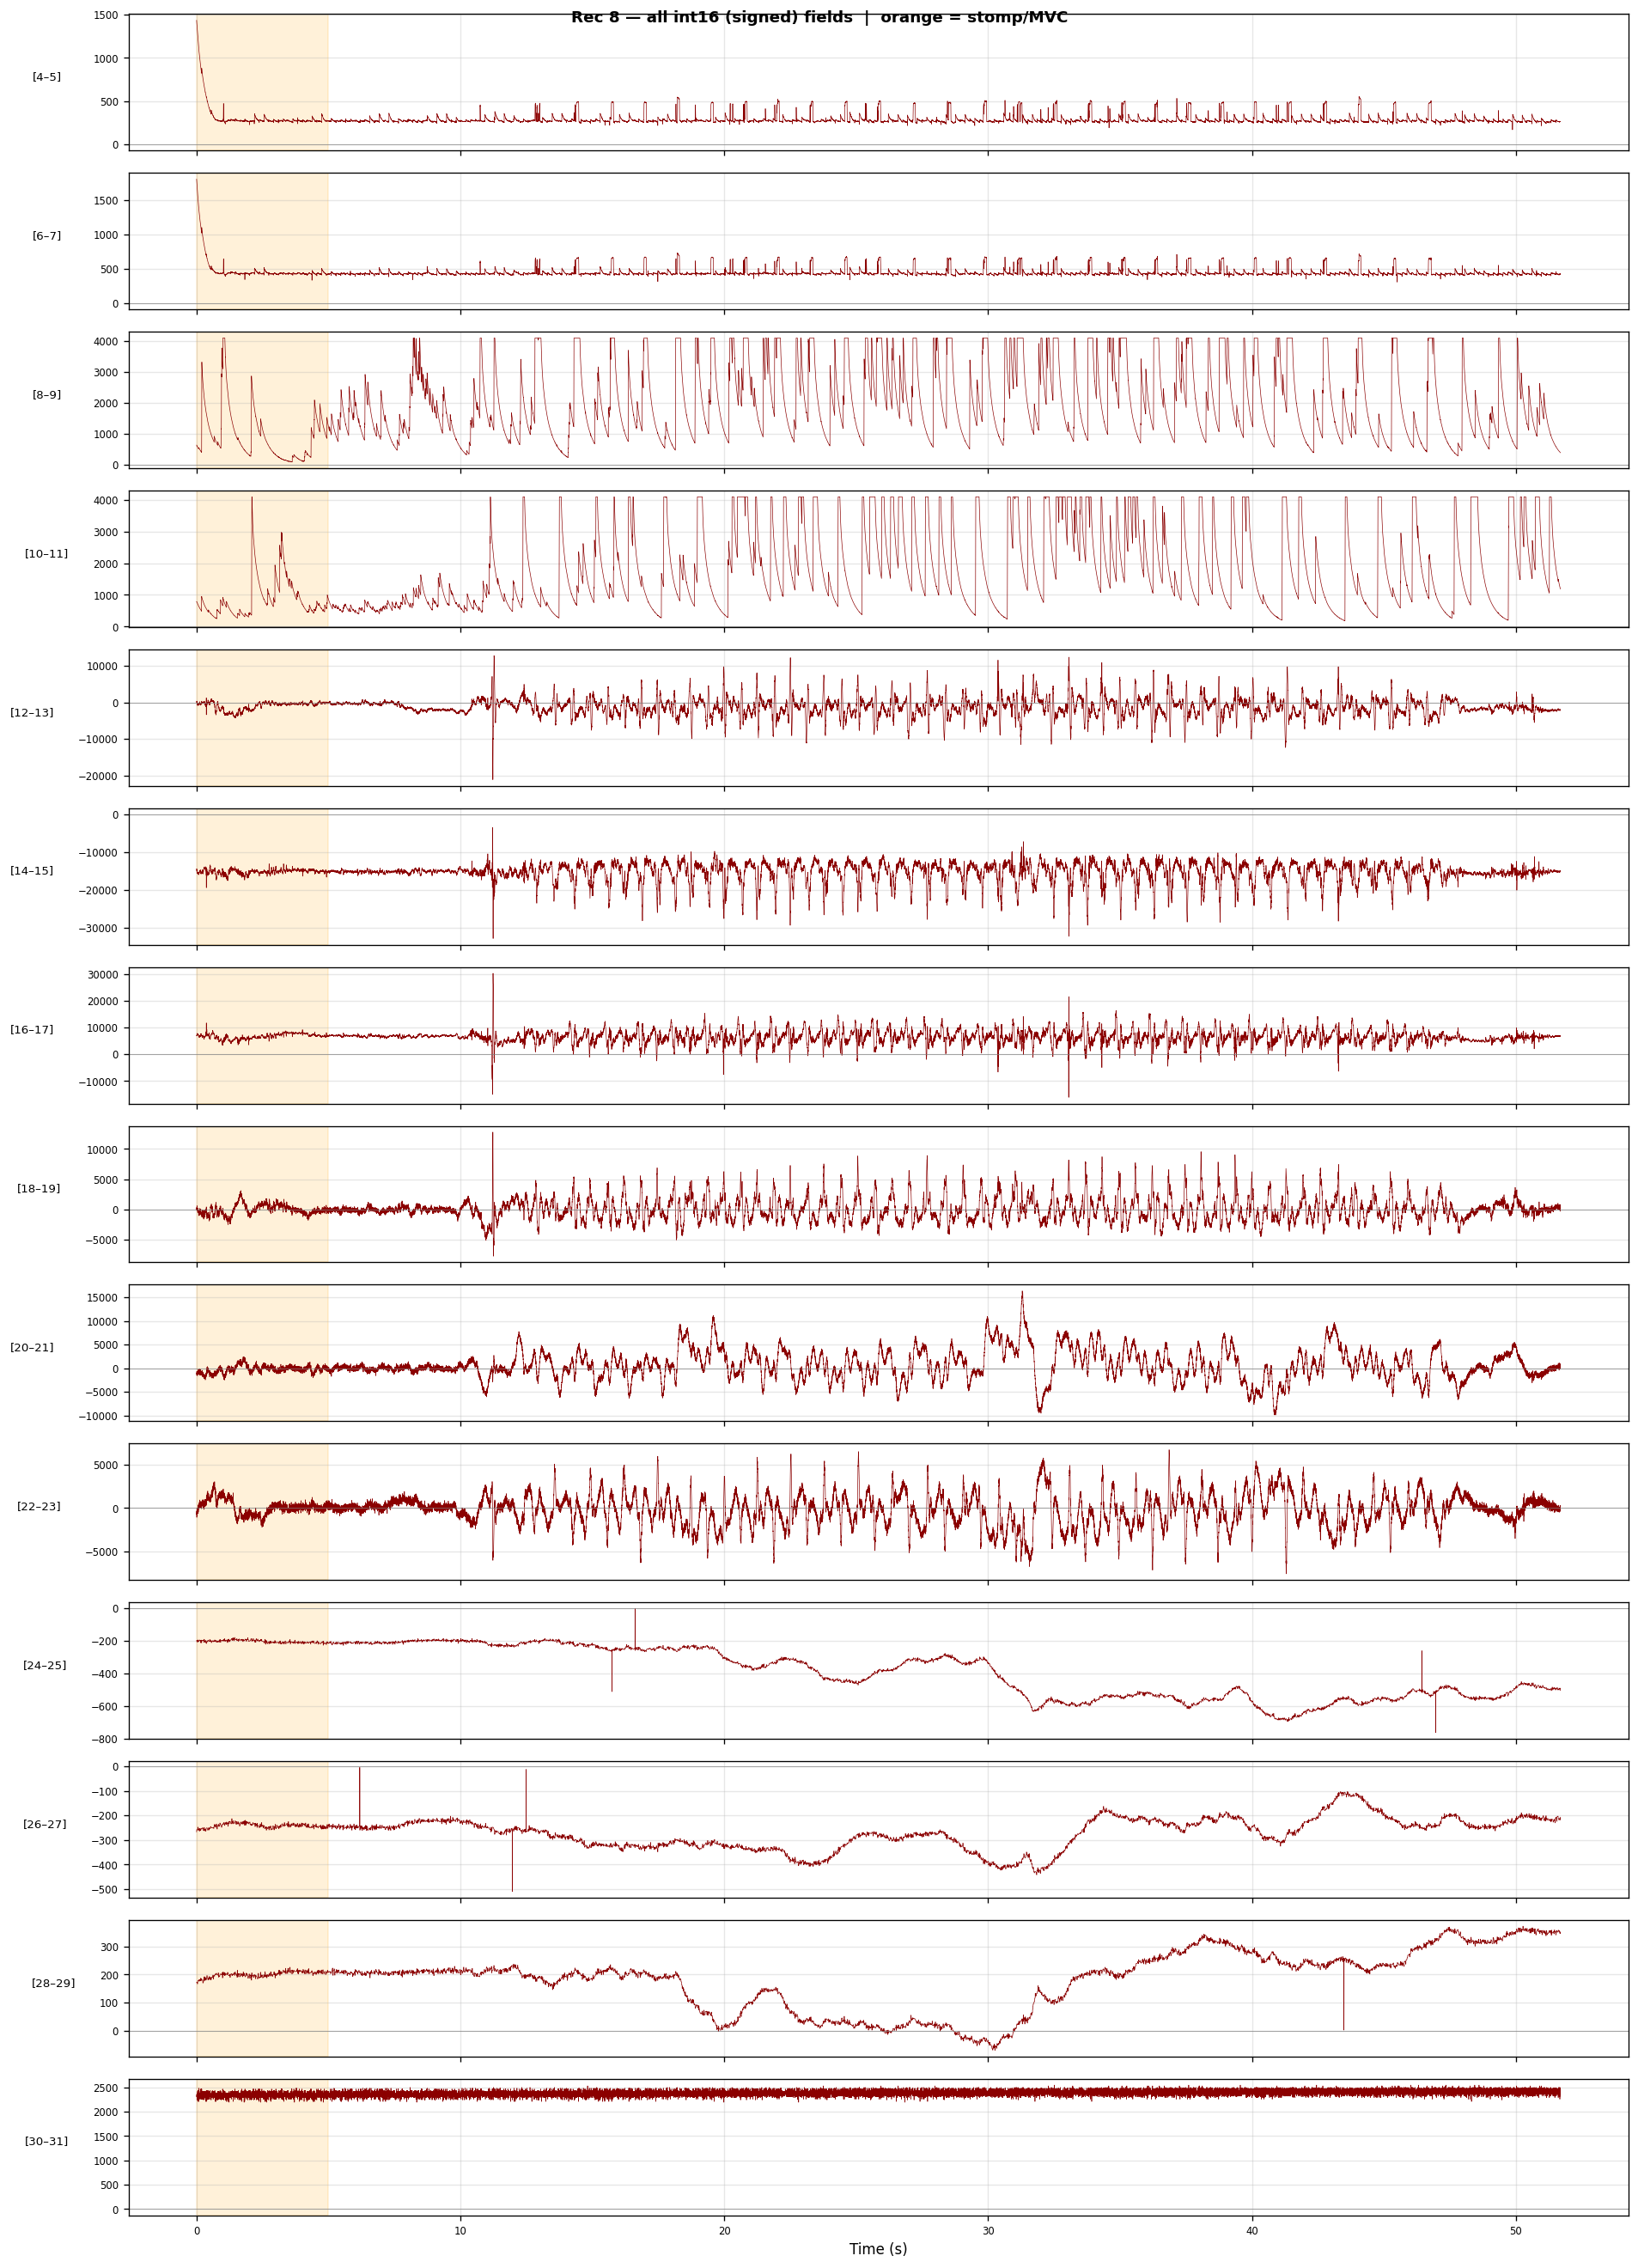

In [26]:
# Same but signed — needed to see IMU going negative
fig, axes = plt.subplots(n_plot, 1, figsize=(16, n_plot * 1.6), sharex=True)
fig.suptitle('Rec 8 — all int16 (signed) fields  |  orange = stomp/MVC', fontsize=11, fontweight='bold')

for ax, off in zip(axes, plot_offsets):
    ax.plot(time8, channels8[off].astype(np.int16), lw=0.4, color='darkred')
    ax.axvspan(0, 5, alpha=0.15, color='orange')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylabel(f'[{off}–{off+1}]', fontsize=8, rotation=0, labelpad=32)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## 6. Zoom — first 15s, candidate EMG offsets
**Update `EMG_OFFSETS` below** based on the plots above.

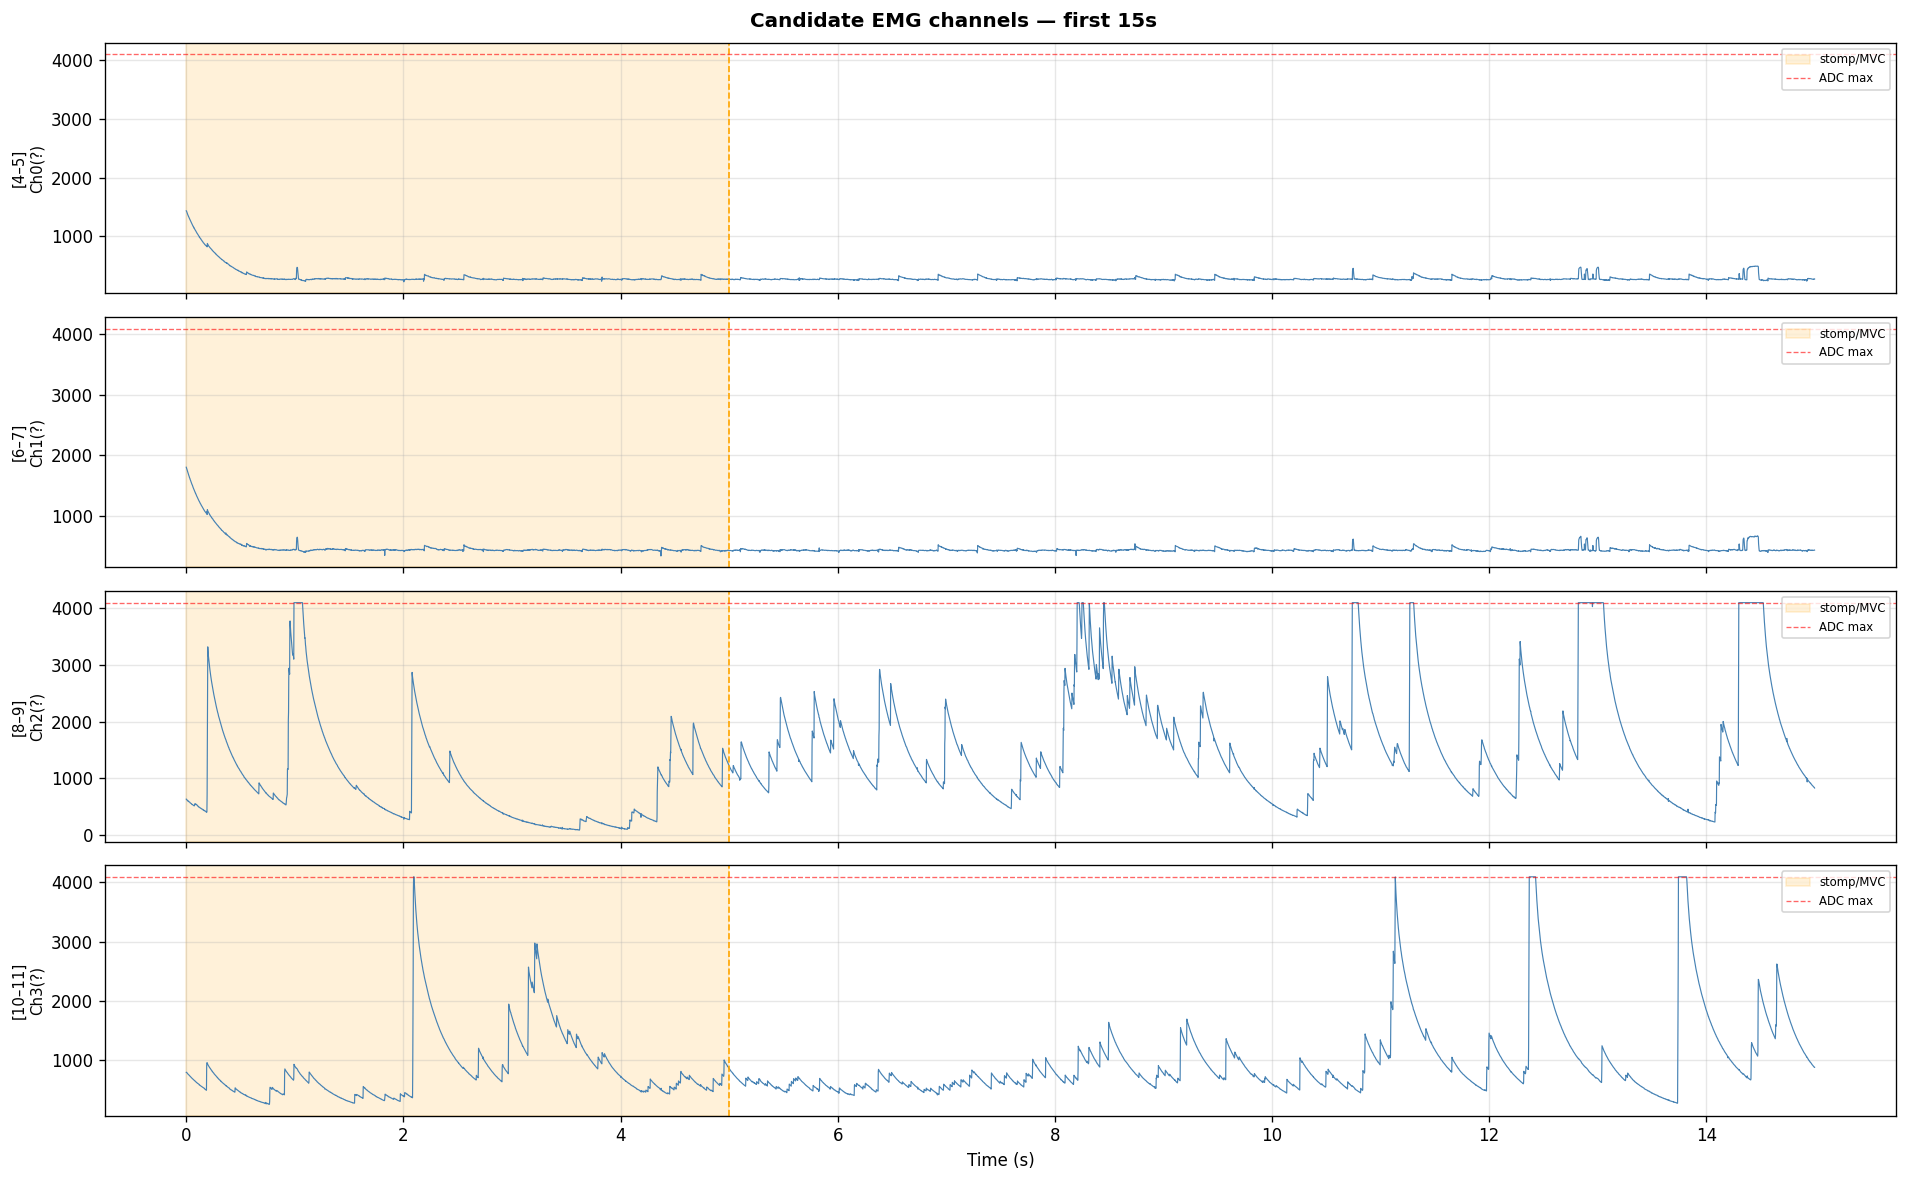

Active EMG: expect bursts during orange stomp window, rhythmic activity after.


In [27]:
# ⚠️ UPDATE THESE once you know the layout
EMG_OFFSETS = [4, 6, 8, 10]   # byte offsets for EMG channels
EMG_LABELS  = ['Ch0(?)', 'Ch1(?)', 'Ch2(?)', 'Ch3(?)']
STOMP_END   = 5.0  # seconds

mask_15 = time8 < 15
fig, axes = plt.subplots(len(EMG_OFFSETS), 1, figsize=(16, len(EMG_OFFSETS)*2.5), sharex=True)
fig.suptitle('Candidate EMG channels — first 15s', fontsize=12, fontweight='bold')

for ax, off, lbl in zip(axes, EMG_OFFSETS, EMG_LABELS):
    ax.plot(time8[mask_15], channels8[off][mask_15], lw=0.7, color='steelblue')
    ax.axvspan(0, STOMP_END, alpha=0.15, color='orange', label='stomp/MVC')
    ax.axvline(STOMP_END, color='orange', lw=1, ls='--')
    ax.axhline(4095, color='red', lw=0.8, ls='--', alpha=0.6, label='ADC max')
    ax.set_ylabel(f'[{off}–{off+1}]\n{lbl}', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()
print("Active EMG: expect bursts during orange stomp window, rhythmic activity after.")

## 7. Spectrograms — check for EMG frequency content
Real EMG = broadband 20–200 Hz. IMU = low freq (<20 Hz). Noise = flat.

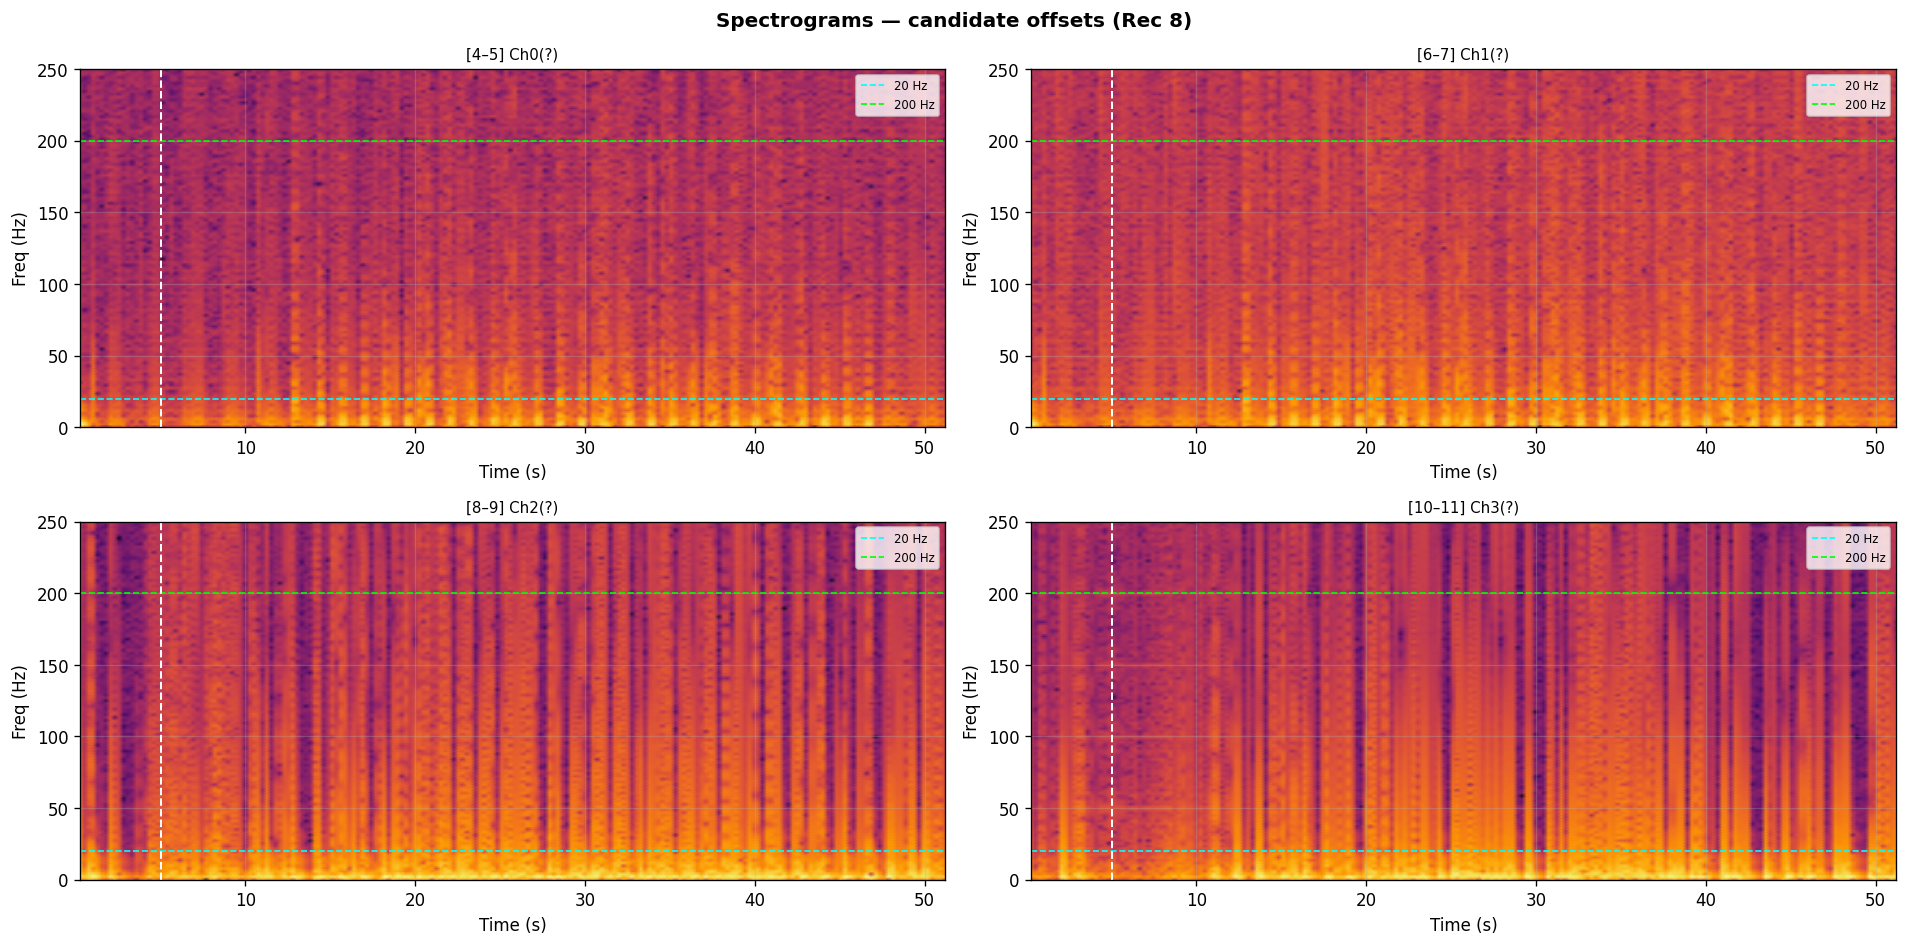

EMG: broadband energy 20–200 Hz increasing during stomps/activity.
IMU: energy concentrated below 20 Hz.


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
fig.suptitle('Spectrograms — candidate offsets (Rec 8)', fontsize=12, fontweight='bold')

for ax, off, lbl in zip(axes, EMG_OFFSETS, EMG_LABELS):
    vals = channels8[off].astype(float) 
    vals -= vals.mean()
    f, t_s, Sxx = signal.spectrogram(vals, fs=FS, nperseg=256, noverlap=128)
    ax.pcolormesh(t_s, f, 10*np.log10(Sxx + 1e-10), shading='gouraud', cmap='inferno')
    ax.axhline(20,  color='cyan', lw=1, ls='--', label='20 Hz')
    ax.axhline(200, color='lime', lw=1, ls='--', label='200 Hz')
    ax.axvline(STOMP_END, color='white', lw=1.2, ls='--')
    ax.set_ylim(0, 250)
    ax.set_title(f'[{off}–{off+1}] {lbl}', fontsize=9)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Freq (Hz)')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print("EMG: broadband energy 20–200 Hz increasing during stomps/activity.")
print("IMU: energy concentrated below 20 Hz.")

## 8. Correlation matrix — find sensor groupings

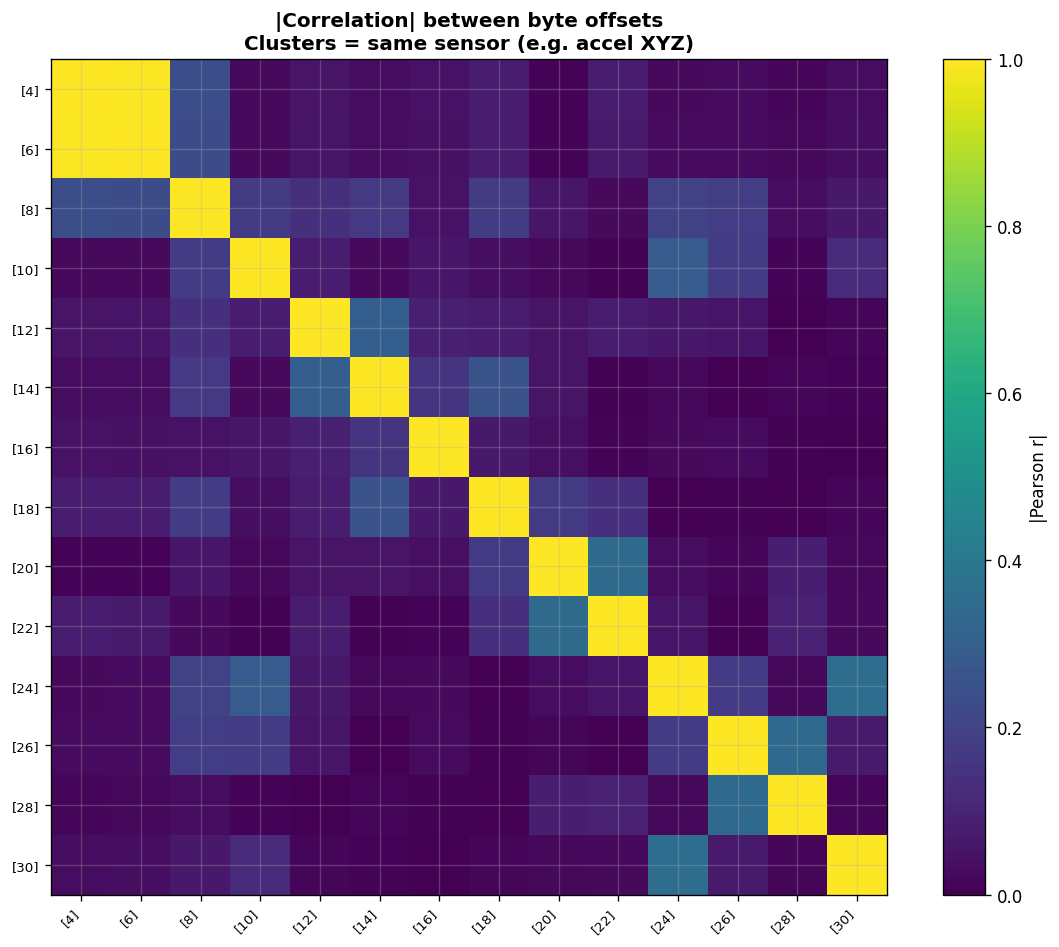

In [29]:
chan_mat = np.stack([channels8[off].astype(float) for off in plot_offsets], axis=1)
corr = np.corrcoef(chan_mat.T)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(np.abs(corr), cmap='viridis', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='|Pearson r|')
labels = [f'[{off}]' for off in plot_offsets]
ax.set_xticks(range(len(plot_offsets))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(plot_offsets))); ax.set_yticklabels(labels, fontsize=8)
ax.set_title('|Correlation| between byte offsets\nClusters = same sensor (e.g. accel XYZ)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⬇️ Processing — UPDATE layout below once Navid confirms the struct
---

In [30]:
# ============================================================
# UPDATE when Navid provides the C struct
# Current best guess (unconfirmed):
#   [0:4]   uint32  timestamp (ms)
#   [4:6]   uint16  EMG Ch0 (RF)
#   [6:8]   uint16  EMG Ch1 (BF)
#   [8:10]  uint16  EMG Ch2 (Gas)
#   [10:12] uint16  EMG Ch3 (TA)
#   [12:30] int16x9 IMU (accel XYZ, gyro XYZ, mag XYZ — order unknown)
#   [30:32] int16   unknown
#   [32]    uint8   0x3F constant
#   [33:45] zeros   padding
# ============================================================

ACTIVE_EMG = {0: 'RF', 1: 'BF'}  # EMG channel index -> muscle name

def parse_emg_bin(path):
    with open(path, 'rb') as f:
        raw = f.read()
    assert struct.unpack('<I', raw[:4])[0]  == 0xDEADBEEF
    assert struct.unpack('<I', raw[-4:])[0] == 0xBEEFDEAD
    payload = raw[4:-4]
    N = len(payload) // RECORD_SIZE
    fmt = '<I 4H 9h'  # 4+8+18 = 30 bytes
    sz  = struct.calcsize(fmt)
    ts  = np.empty(N, dtype=np.uint32)
    emg = np.empty((N, 4), dtype=np.uint16)
    imu = np.empty((N, 9), dtype=np.int16)
    for i in range(N):
        u = struct.unpack(fmt, payload[i*RECORD_SIZE:i*RECORD_SIZE+sz])
        ts[i] = u[0]; emg[i] = u[1:5]; imu[i] = u[5:14]
    time_s = (ts - ts[0]) / 1000.0
    print(f"{Path(path).name}: {N} records, {time_s[-1]:.1f}s")
    return {'time': time_s, 'emg': emg, 'imu': imu, 'N': N, 'path': path}

rec8 = parse_emg_bin('EMG_rec_8.bin')
rec9 = parse_emg_bin('EMG_rec_9.bin')

EMG_rec_8.bin: 25844 records, 51.7s
EMG_rec_9.bin: 34307 records, 68.6s


In [31]:
def process_emg(raw_adc, fs=500, bp=(20, 200), smooth_ms=100):
    """Demean -> bandpass -> rectify -> linear envelope."""
    x = raw_adc.astype(float) - raw_adc.mean()
    nyq = fs / 2
    b, a = signal.butter(4, [bp[0]/nyq, bp[1]/nyq], btype='band')
    filtered = signal.filtfilt(b, a, x)
    b2, a2 = signal.butter(4, (1000/smooth_ms)/nyq, btype='low')
    env = np.clip(signal.filtfilt(b2, a2, np.abs(filtered)), 0, None)
    return filtered, env

def mvc_normalize(env, time_s, mvc_win=(0, 5)):
    mask = (time_s >= mvc_win[0]) & (time_s <= mvc_win[1])
    mvc = np.percentile(env[mask], 95)
    return env / mvc * 100, mvc

for rec in [rec8, rec9]:
    rec['proc'] = {}
    for ch_idx, name in ACTIVE_EMG.items():
        filt, env = process_emg(rec['emg'][:, ch_idx])
        pct, mvc = mvc_normalize(env, rec['time'])
        rec['proc'][name] = {'filtered': filt, 'envelope': env, 'pct_mvc': pct, 'mvc': mvc}
    print(f"{Path(rec['path']).name}: RF MVC={rec['proc']['RF']['mvc']:.1f}, BF MVC={rec['proc']['BF']['mvc']:.1f}")

EMG_rec_8.bin: RF MVC=9.0, BF MVC=11.0
EMG_rec_9.bin: RF MVC=13.5, BF MVC=13.8


## 9. Main EMG + IMU plots

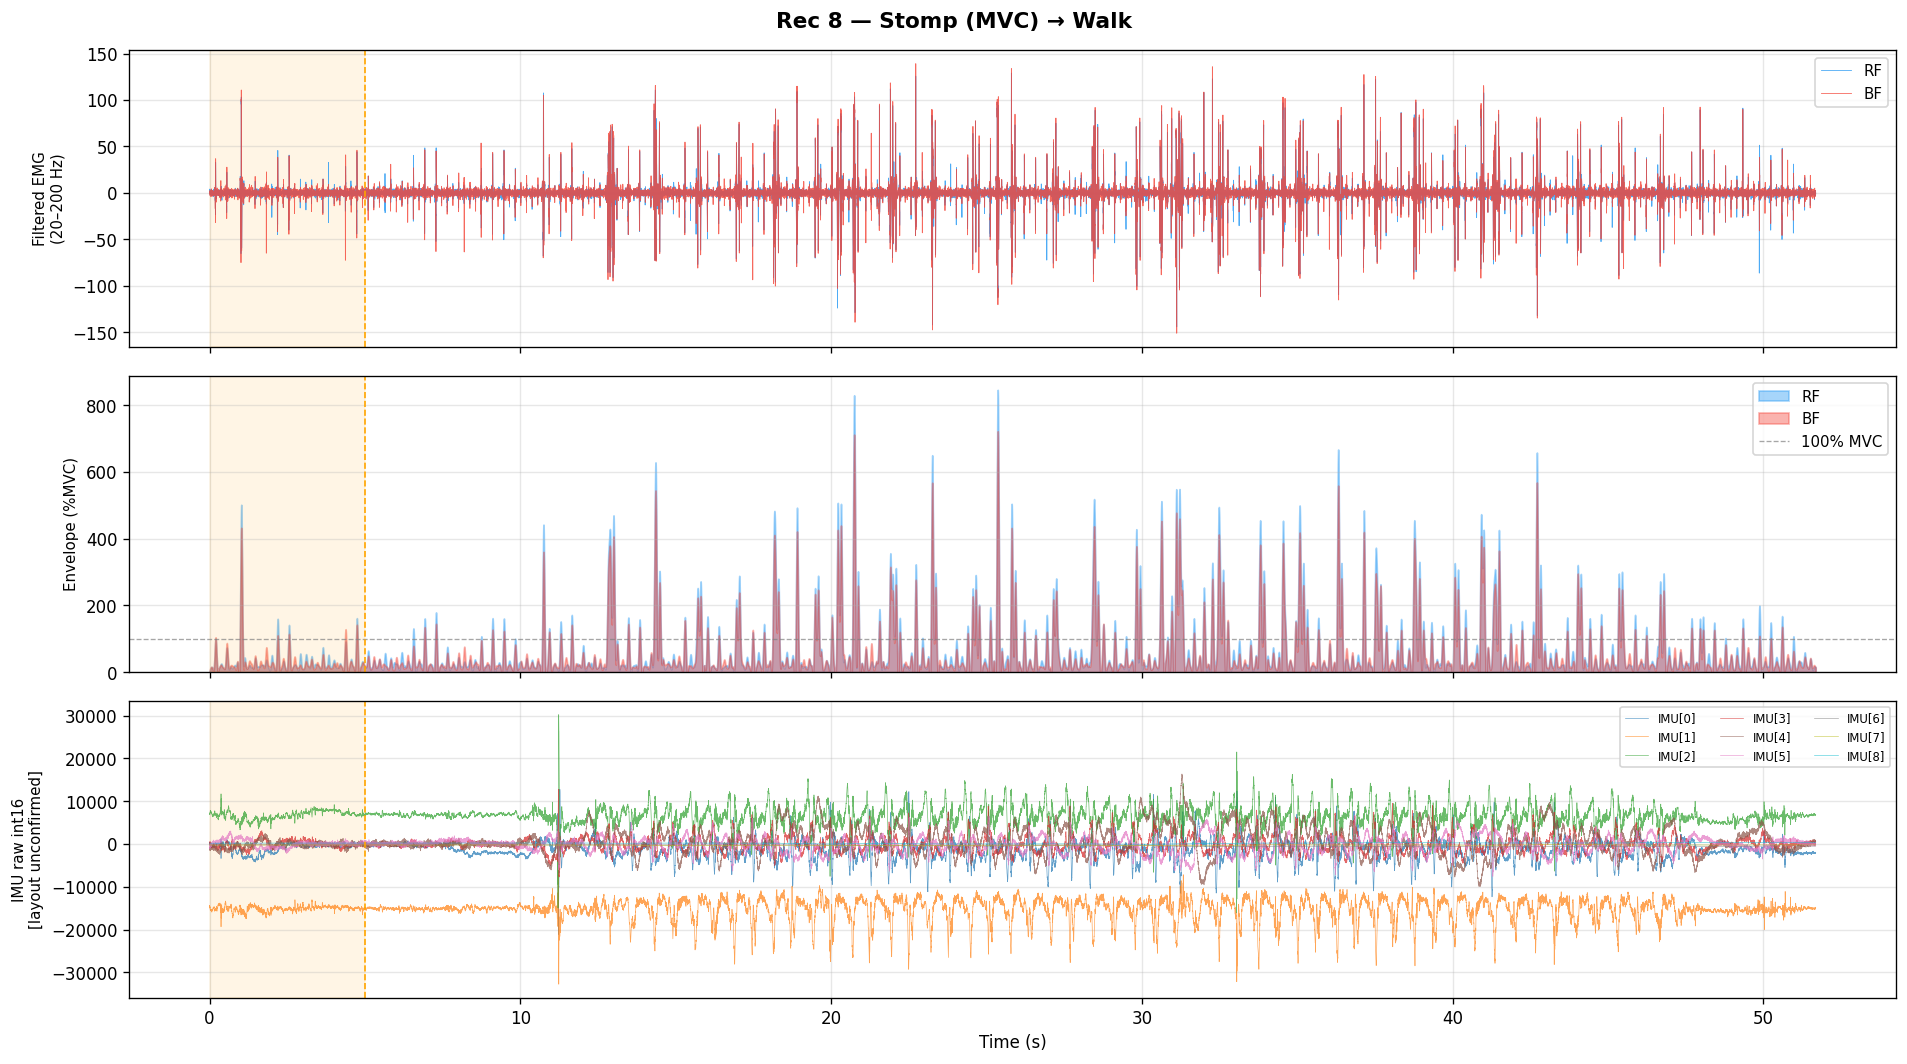

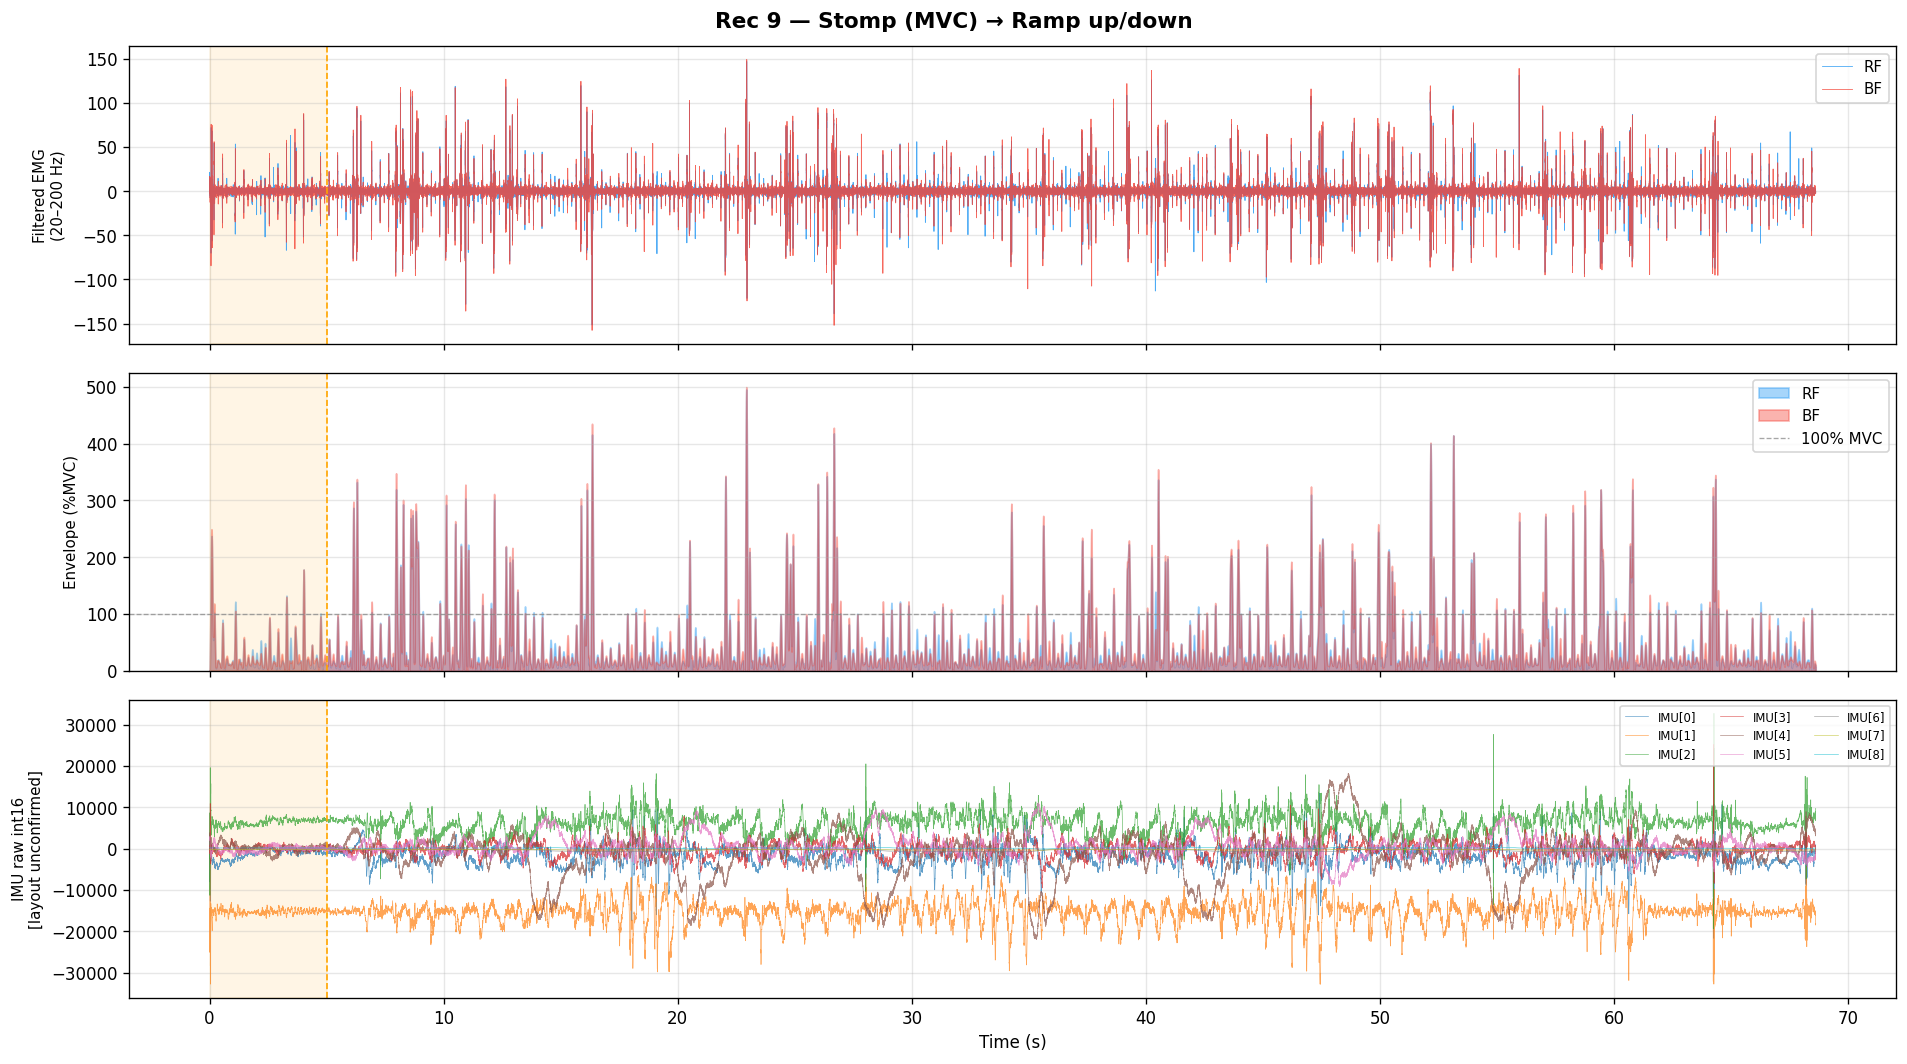

In [32]:
def plot_rec(rec, title):
    t = rec['time']
    fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.plot(t, rec['proc']['RF']['filtered'], color='#2196F3', lw=0.5, alpha=0.8, label='RF')
    ax.plot(t, rec['proc']['BF']['filtered'], color='#F44336', lw=0.5, alpha=0.8, label='BF')
    ax.set_ylabel('Filtered EMG\n(20–200 Hz)', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.axvspan(0, STOMP_END, alpha=0.1, color='orange')
    ax.axvline(STOMP_END, color='orange', lw=1, ls='--')

    ax = axes[1]
    ax.fill_between(t, rec['proc']['RF']['pct_mvc'], alpha=0.4, color='#2196F3', label='RF')
    ax.fill_between(t, rec['proc']['BF']['pct_mvc'], alpha=0.4, color='#F44336', label='BF')
    ax.axhline(100, color='gray', lw=0.8, ls='--', alpha=0.7, label='100% MVC')
    ax.axvspan(0, STOMP_END, alpha=0.1, color='orange')
    ax.axvline(STOMP_END, color='orange', lw=1, ls='--')
    ax.set_ylabel('Envelope (%MVC)', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0, None)

    ax = axes[2]
    colors = plt.cm.tab10(np.linspace(0, 1, 9))
    imu_labels = ['IMU[0]','IMU[1]','IMU[2]','IMU[3]','IMU[4]','IMU[5]','IMU[6]','IMU[7]','IMU[8]']
    for i in range(9):
        ax.plot(t, rec['imu'][:, i], lw=0.4, alpha=0.7, color=colors[i], label=imu_labels[i])
    ax.axvspan(0, STOMP_END, alpha=0.1, color='orange')
    ax.axvline(STOMP_END, color='orange', lw=1, ls='--')
    ax.set_ylabel('IMU raw int16\n[layout unconfirmed]', fontsize=9)
    ax.set_xlabel('Time (s)')
    ax.legend(ncol=3, fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.show()

plot_rec(rec8, 'Rec 8 — Stomp (MVC) → Walk')
plot_rec(rec9, 'Rec 9 — Stomp (MVC) → Ramp up/down')

## 10. Walk vs Ramp — locomotion phase only

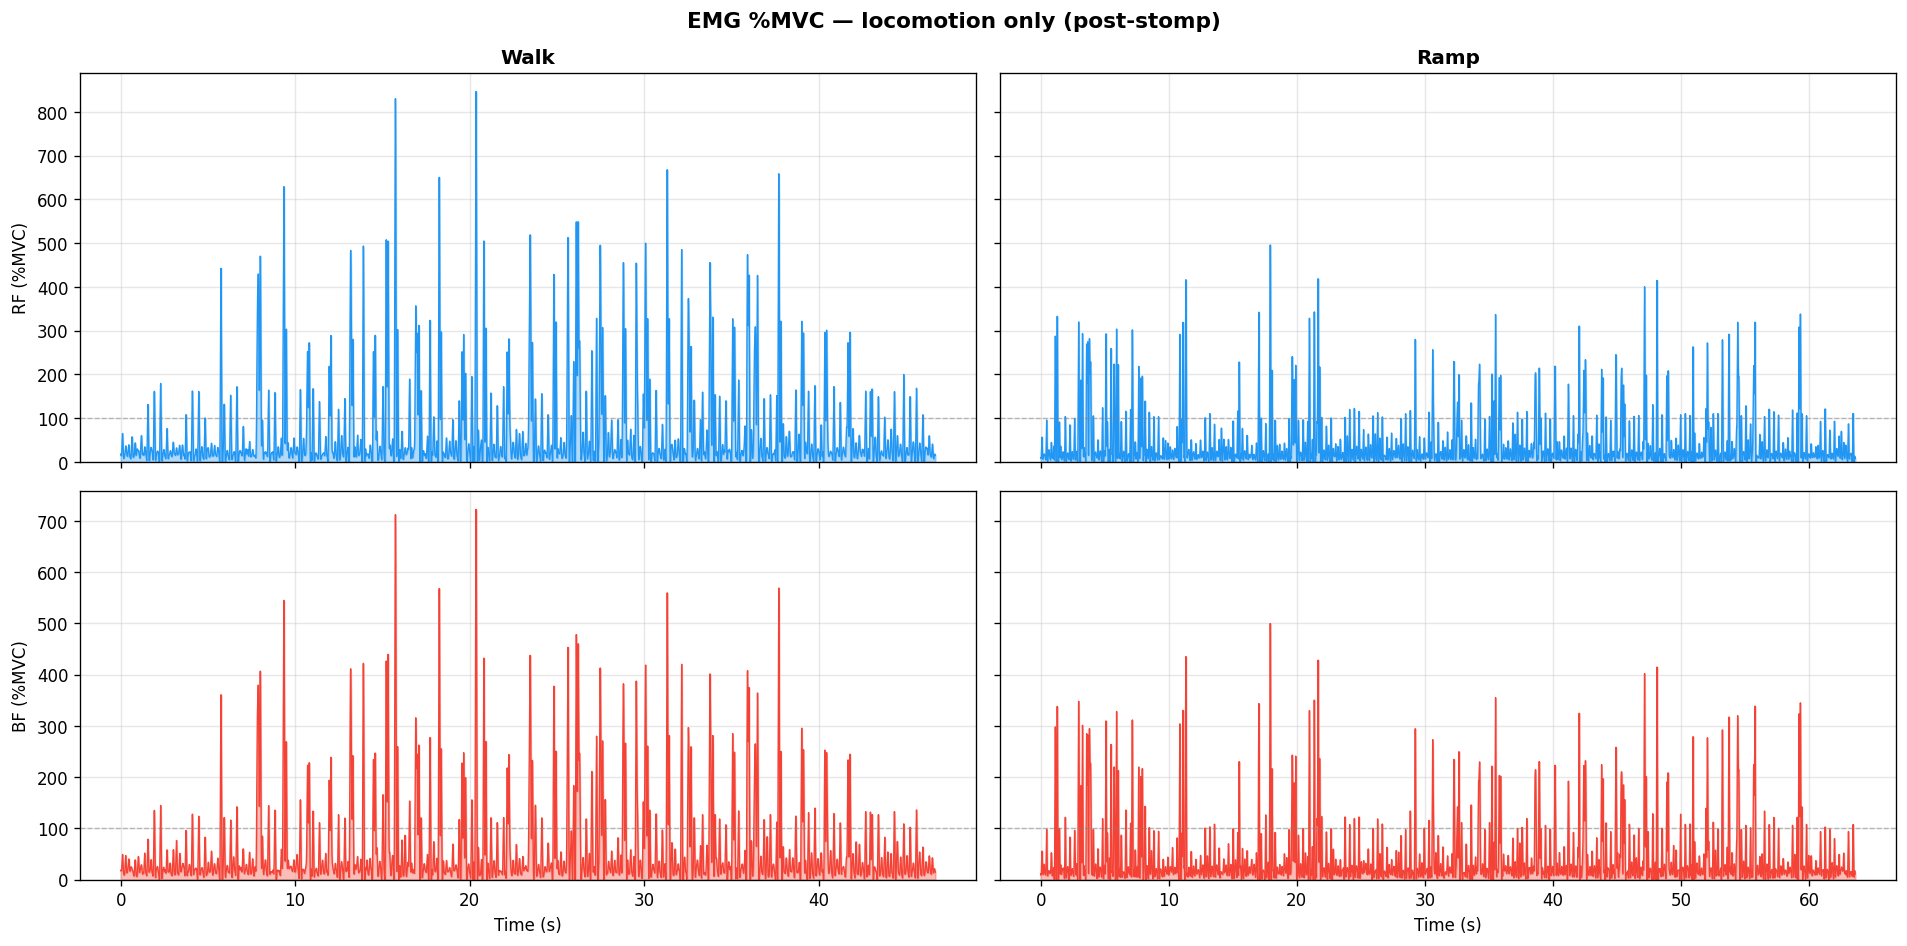

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex='col', sharey='row')
fig.suptitle('EMG %MVC — locomotion only (post-stomp)', fontsize=13, fontweight='bold')

for col, (rec, task) in enumerate([(rec8, 'Walk'), (rec9, 'Ramp')]):
    mask = rec['time'] >= STOMP_END
    t = rec['time'][mask] - STOMP_END
    for row, muscle in enumerate(['RF', 'BF']):
        ax = axes[row, col]
        pct = rec['proc'][muscle]['pct_mvc'][mask]
        color = '#2196F3' if muscle == 'RF' else '#F44336'
        ax.fill_between(t, pct, alpha=0.35, color=color)
        ax.plot(t, pct, color=color, lw=0.8)
        ax.axhline(100, color='gray', lw=0.8, ls='--', alpha=0.5)
        if row == 0: ax.set_title(task, fontweight='bold')
        if col == 0: ax.set_ylabel(f'{muscle} (%MVC)', fontsize=10)
        if row == 1: ax.set_xlabel('Time (s)')
        ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

## TODO
- [ ] **Ask Navid for the C struct** — confirm byte offsets, IMU field order & scale factors
- [ ] **Update `EMG_OFFSETS`** in cell 6 based on inspection plots
- [ ] **Update `ACTIVE_EMG`** if RF/BF are on different channel indices
- [ ] **Adjust `STOMP_END`** if MVC window is a different duration
- [ ] **Add motor torque field** once Navid updates format
- [ ] **Label ramp phases** in Rec 9 (uphill vs downhill)
- [ ] **Gait segmentation** via IMU once axes confirmed